In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
import json
import math
import re
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
from PIL import Image

try:
    from scipy import ndimage as ndi
except ImportError:
    ndi = None


# =========================================================
# DATACLASSES
# =========================================================

@dataclass
class CaseIdentity:
    case_key: str          # ejemplo: S_21 o N_7
    prefix: str            # S o N
    patient_number: int    # 21, 7, etc.
    diagnosis: str         # scoliosis | normal


@dataclass
class ImageCaseRecord:
    case_key: str
    prefix: str
    patient_number: int
    diagnosis: str
    gray_mask_path: Optional[str] = None
    radiograph_path: Optional[str] = None


@dataclass
class GrayBlobInfo:
    class_id: int
    class_name: str
    area: int
    bbox: Tuple[int, int, int, int]   # (ymin, xmin, ymax, xmax)
    centroid: Tuple[float, float]     # (y, x)


@dataclass
class GrayClassSummary:
    class_id: int
    class_name: str
    gray_expected: Optional[int]
    pixel_count: int
    present: bool
    num_components: int = 0
    mean_distance: Optional[float] = None
    weak: bool = False
    ambiguous: bool = False
    note: str = ""


@dataclass
class GrayDuplicateReport:
    case_key: str
    diagnosis: str
    class_id: int
    class_name: str
    discarded_area: int
    kept_area: int
    discarded_bbox: Tuple[int, int, int, int]
    kept_bbox: Tuple[int, int, int, int]
    intersection: int
    union: int
    overlap_small: float
    iou: float
    reason: str


@dataclass
class ExtractedRegionInfo:
    case_key: str
    diagnosis: str
    class_id: int
    class_name: str
    blob_index: int
    area: int
    bbox: Tuple[int, int, int, int]
    crop_path: Optional[str] = None


# =========================================================
# MAIN CLASS
# =========================================================

class VertebraGrayImageOnlyProcessor:
    """
    Procesador basado solo en imágenes.

    Convención soportada en nombres:
      S_21.png
      S21_mask.png
      S-21-radiograph.jpg
      N_7_mask.png
      N7.png

    Regla:
      S -> scoliosis
      N -> normal

    El emparejamiento máscara/radiografía se hace por case_key = <prefix>_<numero>.
    """

    CASE_REGEX = re.compile(r'(?i)(^|[^A-Za-z0-9])([SN])[_\-]?(\d+)([^A-Za-z0-9]|$)')

    def __init__(
        self,
        class_id_to_name: Dict[int, str],
        class_id_to_gray: Dict[int, int]
    ):
        self.class_id_to_name: Dict[int, str] = {int(k): v for k, v in class_id_to_name.items()}
        self.class_id_to_gray: Dict[int, int] = {int(k): int(v) for k, v in class_id_to_gray.items()}

        self.name_to_class_id: Dict[str, int] = {
            name: class_id for class_id, name in self.class_id_to_name.items()
        }

        self.palette_class_ids = np.array(sorted(self.class_id_to_gray.keys()), dtype=np.int32)
        self.palette_gray = np.array(
            [self.class_id_to_gray[cid] for cid in self.palette_class_ids],
            dtype=np.int16
        )

        self.case_index: Dict[str, ImageCaseRecord] = {}

        # contexto actual
        self.current_case: Optional[ImageCaseRecord] = None
        self.case_key: Optional[str] = None
        self.diagnosis: Optional[str] = None
        self.patient_number: Optional[int] = None

        self.image_path: Optional[str] = None          # máscara gray
        self.radiograph_path: Optional[str] = None     # radiografía

        self.image_gray: Optional[np.ndarray] = None
        self.radiograph_image: Optional[np.ndarray] = None

        self.class_id_matrix: Optional[np.ndarray] = None
        self.distance_matrix: Optional[np.ndarray] = None
        self.unknown_mask: Optional[np.ndarray] = None

        self.masks_by_class: Dict[int, np.ndarray] = {}
        self.blobs_by_class: Dict[int, List[GrayBlobInfo]] = {}
        self.blob_masks_by_class: Dict[int, List[np.ndarray]] = {}
        self.duplicate_reports: List[GrayDuplicateReport] = []
        self.summaries: List[GrayClassSummary] = []

    # -----------------------------------------------------
    # UTILIDADES DE IDENTIDAD DEL CASO
    # -----------------------------------------------------

    @classmethod
    def infer_case_identity_from_path(cls, image_path: str) -> CaseIdentity:
        """
        Extrae S_num o N_num del nombre del archivo.

        Ejemplos válidos:
          S_21_mask.png -> S_21
          N7.png        -> N_7
          xray-S-14.jpg -> S_14
        """
        stem = Path(image_path).stem
        match = cls.CASE_REGEX.search(f" {stem} ")
        if not match:
            raise ValueError(
                f"No se pudo inferir S_num o N_num desde el archivo: {image_path}"
            )

        prefix = match.group(2).upper()
        patient_number = int(match.group(3))
        case_key = f"{prefix}_{patient_number}"
        diagnosis = "scoliosis" if prefix == "S" else "normal"

        return CaseIdentity(
            case_key=case_key,
            prefix=prefix,
            patient_number=patient_number,
            diagnosis=diagnosis
        )

    def reset_state(self) -> None:
        self.current_case = None
        self.case_key = None
        self.diagnosis = None
        self.patient_number = None
        self.image_path = None
        self.radiograph_path = None
        self.image_gray = None
        self.radiograph_image = None
        self.class_id_matrix = None
        self.distance_matrix = None
        self.unknown_mask = None
        self.masks_by_class = {}
        self.blobs_by_class = {}
        self.blob_masks_by_class = {}
        self.duplicate_reports = []
        self.summaries = []

    # -----------------------------------------------------
    # REGISTRO Y SCAN DE IMÁGENES
    # -----------------------------------------------------

    def register_mask_image(self, gray_mask_path: str) -> str:
        identity = self.infer_case_identity_from_path(gray_mask_path)
        record = self.case_index.get(identity.case_key)

        if record is None:
            record = ImageCaseRecord(
                case_key=identity.case_key,
                prefix=identity.prefix,
                patient_number=identity.patient_number,
                diagnosis=identity.diagnosis,
                gray_mask_path=str(gray_mask_path),
                radiograph_path=None
            )
            self.case_index[identity.case_key] = record
        else:
            record.gray_mask_path = str(gray_mask_path)

        return identity.case_key

    def register_radiograph_image(self, radiograph_path: str) -> str:
        identity = self.infer_case_identity_from_path(radiograph_path)
        record = self.case_index.get(identity.case_key)

        if record is None:
            record = ImageCaseRecord(
                case_key=identity.case_key,
                prefix=identity.prefix,
                patient_number=identity.patient_number,
                diagnosis=identity.diagnosis,
                gray_mask_path=None,
                radiograph_path=str(radiograph_path)
            )
            self.case_index[identity.case_key] = record
        else:
            record.radiograph_path = str(radiograph_path)

        return identity.case_key

    def scan_directories(
        self,
        mask_dir: Optional[str] = None,
        radiograph_dir: Optional[str] = None,
        extensions: Tuple[str, ...] = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
    ) -> None:
        """
        Escanea directorios y empareja por S_num o N_num.
        """
        if mask_dir is not None:
            for p in sorted(Path(mask_dir).rglob("*")):
                if p.is_file() and p.suffix.lower() in extensions:
                    try:
                        self.register_mask_image(str(p))
                    except ValueError:
                        pass

        if radiograph_dir is not None:
            for p in sorted(Path(radiograph_dir).rglob("*")):
                if p.is_file() and p.suffix.lower() in extensions:
                    try:
                        self.register_radiograph_image(str(p))
                    except ValueError:
                        pass

    def get_registered_cases(self) -> List[str]:
        return sorted(self.case_index.keys())

    # -----------------------------------------------------
    # CARGA DE CASO
    # -----------------------------------------------------

    def load_case(self, case_key: str) -> None:
        if case_key not in self.case_index:
            raise KeyError(f"No existe case_key={case_key} en el índice.")

        self.reset_state()
        case = self.case_index[case_key]
        self.current_case = case
        self.case_key = case.case_key
        self.diagnosis = case.diagnosis
        self.patient_number = case.patient_number

        if case.gray_mask_path is not None:
            self.load_gray_mask(case.gray_mask_path)

        if case.radiograph_path is not None:
            self.load_radiograph(case.radiograph_path)

    def load_case_from_paths(
        self,
        gray_mask_path: str,
        radiograph_path: Optional[str] = None
    ) -> None:
        """
        Carga directa sin índice, infiriendo la identidad desde el nombre del archivo.
        """
        identity = self.infer_case_identity_from_path(gray_mask_path)

        self.reset_state()
        self.current_case = ImageCaseRecord(
            case_key=identity.case_key,
            prefix=identity.prefix,
            patient_number=identity.patient_number,
            diagnosis=identity.diagnosis,
            gray_mask_path=str(gray_mask_path),
            radiograph_path=str(radiograph_path) if radiograph_path else None
        )
        self.case_key = identity.case_key
        self.diagnosis = identity.diagnosis
        self.patient_number = identity.patient_number

        self.load_gray_mask(gray_mask_path)

        if radiograph_path is not None:
            rad_identity = self.infer_case_identity_from_path(radiograph_path)
            if rad_identity.case_key != identity.case_key:
                raise ValueError(
                    f"La máscara ({identity.case_key}) y la radiografía ({rad_identity.case_key}) no coinciden."
                )
            self.load_radiograph(radiograph_path)

    def load_gray_mask(self, image_path: str) -> None:
        self.image_path = str(image_path)
        self.image_gray = np.array(Image.open(image_path).convert("L")).astype(np.int16)

    def load_radiograph(self, radiograph_path: str) -> None:
        self.radiograph_path = str(radiograph_path)
        self.radiograph_image = np.array(Image.open(radiograph_path))

    def _require_mask(self) -> None:
        if self.image_gray is None:
            raise ValueError("No hay máscara gray cargada.")

    def _require_radiograph(self) -> None:
        if self.radiograph_image is None:
            raise ValueError("No hay radiografía cargada.")

    def _require_case(self) -> None:
        if self.case_key is None:
            raise ValueError("No hay caso cargado.")

    # -----------------------------------------------------
    # CLASIFICACIÓN GRAY CANÓNICA
    # -----------------------------------------------------

    def classify_pixels_gray_nearest(
        self,
        tolerance: int = 4,
        unknown_class_id: int = -1
    ) -> np.ndarray:
        self._require_mask()

        h, w = self.image_gray.shape
        pixels = self.image_gray.reshape(-1, 1)

        dists = np.abs(pixels - self.palette_gray[None, :])
        nearest_idx = np.argmin(dists, axis=1)
        nearest_dist = np.min(dists, axis=1)
        nearest_class_ids = self.palette_class_ids[nearest_idx]

        assigned = np.where(nearest_dist <= tolerance, nearest_class_ids, unknown_class_id)

        self.class_id_matrix = assigned.reshape(h, w)
        self.distance_matrix = nearest_dist.reshape(h, w)
        self.unknown_mask = (self.class_id_matrix == unknown_class_id)
        self._generate_masks()

        return self.class_id_matrix

    def _generate_masks(self) -> None:
        if self.class_id_matrix is None:
            raise ValueError("Ejecuta classify_pixels_gray_nearest() primero.")

        self.masks_by_class = {
            int(cid): (self.class_id_matrix == cid)
            for cid in self.palette_class_ids
        }

    # -----------------------------------------------------
    # CONNECTED COMPONENTS
    # -----------------------------------------------------

    def _connected_components(self, mask: np.ndarray) -> Tuple[np.ndarray, int]:
        if ndi is None:
            raise ImportError("Se requiere scipy para connected components.")
        structure = np.ones((3, 3), dtype=np.int8)
        labeled, num = ndi.label(mask.astype(np.uint8), structure=structure)
        return labeled, int(num)

    def _bbox_intersects(
        self,
        bbox_a: Tuple[int, int, int, int],
        bbox_b: Tuple[int, int, int, int]
    ) -> bool:
        ay1, ax1, ay2, ax2 = bbox_a
        by1, bx1, by2, bx2 = bbox_b

        if ay2 < by1 or by2 < ay1:
            return False
        if ax2 < bx1 or bx2 < ax1:
            return False
        return True

    def _build_blob_info(self, class_id: int, comp_mask: np.ndarray) -> GrayBlobInfo:
        ys, xs = np.where(comp_mask)
        ymin, ymax = int(ys.min()), int(ys.max())
        xmin, xmax = int(xs.min()), int(xs.max())
        centroid_y = float(ys.mean())
        centroid_x = float(xs.mean())
        area = int(comp_mask.sum())

        return GrayBlobInfo(
            class_id=int(class_id),
            class_name=self.class_id_to_name.get(int(class_id), str(class_id)),
            area=area,
            bbox=(ymin, xmin, ymax, xmax),
            centroid=(centroid_y, centroid_x),
        )

    # -----------------------------------------------------
    # DEDUPLICACIÓN
    # -----------------------------------------------------

    def _region_overlap_metrics(self, mask_a: np.ndarray, mask_b: np.ndarray) -> Dict[str, float]:
        area_a = int(mask_a.sum())
        area_b = int(mask_b.sum())

        if area_a == 0 or area_b == 0:
            return {
                "area_a": area_a,
                "area_b": area_b,
                "intersection": 0,
                "union": 0,
                "overlap_small": 0.0,
                "iou": 0.0,
            }

        intersection = int(np.logical_and(mask_a, mask_b).sum())
        union = int(np.logical_or(mask_a, mask_b).sum())

        overlap_small = intersection / max(1, min(area_a, area_b))
        iou = intersection / max(1, union)

        return {
            "area_a": area_a,
            "area_b": area_b,
            "intersection": intersection,
            "union": union,
            "overlap_small": float(overlap_small),
            "iou": float(iou),
        }

    def _regions_are_duplicate(
        self,
        blob_a: GrayBlobInfo,
        mask_a: np.ndarray,
        blob_b: GrayBlobInfo,
        mask_b: np.ndarray,
        overlap_threshold: float = 0.80,
        iou_threshold: float = 0.50
    ) -> Tuple[bool, Dict[str, float], str]:
        if not self._bbox_intersects(blob_a.bbox, blob_b.bbox):
            metrics = {
                "area_a": blob_a.area,
                "area_b": blob_b.area,
                "intersection": 0,
                "union": blob_a.area + blob_b.area,
                "overlap_small": 0.0,
                "iou": 0.0,
            }
            return False, metrics, "bbox_disjoint"

        metrics = self._region_overlap_metrics(mask_a, mask_b)

        if metrics["intersection"] == 0:
            return False, metrics, "no_pixel_intersection"

        if metrics["overlap_small"] >= overlap_threshold:
            return True, metrics, "overlap_small"

        if metrics["iou"] >= iou_threshold:
            return True, metrics, "iou"

        return False, metrics, "below_threshold"

    def _deduplicate_class_components(
        self,
        class_id: int,
        blobs: List[GrayBlobInfo],
        masks: List[np.ndarray],
        overlap_threshold: float = 0.80,
        iou_threshold: float = 0.50
    ) -> Tuple[List[GrayBlobInfo], List[np.ndarray]]:
        if not blobs:
            return [], []

        order = sorted(range(len(blobs)), key=lambda i: blobs[i].area, reverse=True)

        kept_blob_indices: List[int] = []
        local_reports: List[GrayDuplicateReport] = []

        for idx in order:
            current_blob = blobs[idx]
            current_mask = masks[idx]
            discard_current = False

            for kept_idx in kept_blob_indices:
                kept_blob = blobs[kept_idx]
                kept_mask = masks[kept_idx]

                is_dup, metrics, reason = self._regions_are_duplicate(
                    current_blob,
                    current_mask,
                    kept_blob,
                    kept_mask,
                    overlap_threshold=overlap_threshold,
                    iou_threshold=iou_threshold
                )

                if is_dup:
                    local_reports.append(
                        GrayDuplicateReport(
                            case_key=self.case_key or "UNKNOWN",
                            diagnosis=self.diagnosis or "UNKNOWN",
                            class_id=int(class_id),
                            class_name=self.class_id_to_name.get(int(class_id), str(class_id)),
                            discarded_area=current_blob.area,
                            kept_area=kept_blob.area,
                            discarded_bbox=current_blob.bbox,
                            kept_bbox=kept_blob.bbox,
                            intersection=int(metrics["intersection"]),
                            union=int(metrics["union"]),
                            overlap_small=float(metrics["overlap_small"]),
                            iou=float(metrics["iou"]),
                            reason=reason,
                        )
                    )
                    discard_current = True
                    break

            if not discard_current:
                kept_blob_indices.append(idx)

        kept_blobs = [blobs[i] for i in kept_blob_indices]
        kept_masks = [masks[i] for i in kept_blob_indices]

        self.duplicate_reports.extend(local_reports)
        return kept_blobs, kept_masks

    def extract_connected_components(
        self,
        min_area: int = 10,
        deduplicate: bool = True,
        overlap_threshold: float = 0.80,
        iou_threshold: float = 0.50
    ) -> Dict[int, List[GrayBlobInfo]]:
        if self.class_id_matrix is None:
            raise ValueError("Ejecuta classify_pixels_gray_nearest() primero.")

        self.blobs_by_class = {}
        self.blob_masks_by_class = {}
        self.duplicate_reports = []

        for class_id, mask in self.masks_by_class.items():
            labeled, num = self._connected_components(mask)

            blobs: List[GrayBlobInfo] = []
            masks: List[np.ndarray] = []

            for comp_id in range(1, num + 1):
                comp_mask = (labeled == comp_id)
                area = int(comp_mask.sum())
                if area < min_area:
                    continue

                blob = self._build_blob_info(int(class_id), comp_mask)
                blobs.append(blob)
                masks.append(comp_mask)

            if deduplicate and blobs:
                blobs, masks = self._deduplicate_class_components(
                    class_id=int(class_id),
                    blobs=blobs,
                    masks=masks,
                    overlap_threshold=overlap_threshold,
                    iou_threshold=iou_threshold
                )

            sorted_pairs = sorted(zip(blobs, masks), key=lambda pair: pair[0].centroid[0])
            if sorted_pairs:
                blobs = [p[0] for p in sorted_pairs]
                masks = [p[1] for p in sorted_pairs]
            else:
                blobs = []
                masks = []

            self.blobs_by_class[int(class_id)] = blobs
            self.blob_masks_by_class[int(class_id)] = masks

        return self.blobs_by_class

    # -----------------------------------------------------
    # RESUMEN
    # -----------------------------------------------------

    def compute_summary(self, weak_area_threshold: int = 50) -> List[GrayClassSummary]:
        if self.class_id_matrix is None:
            raise ValueError("Ejecuta classify_pixels_gray_nearest() primero.")
        if not self.blobs_by_class:
            self.extract_connected_components()

        present_non_bg_counts = []
        for class_id in self.palette_class_ids:
            if class_id == 0:
                continue
            pixel_count = int(np.sum(self.class_id_matrix == class_id))
            if pixel_count > 0:
                present_non_bg_counts.append(pixel_count)

        median_present = float(np.median(present_non_bg_counts)) if present_non_bg_counts else 0.0

        summaries: List[GrayClassSummary] = []
        for class_id in self.palette_class_ids:
            class_id = int(class_id)
            name = self.class_id_to_name.get(class_id, str(class_id))
            gray_expected = self.class_id_to_gray.get(class_id)

            pixel_count = int(np.sum(self.class_id_matrix == class_id))
            present = pixel_count > 0
            blobs = self.blobs_by_class.get(class_id, [])
            num_components = len(blobs)

            mean_distance = None
            if self.distance_matrix is not None and present:
                mask = self.class_id_matrix == class_id
                vals = self.distance_matrix[mask]
                mean_distance = float(vals.mean()) if vals.size > 0 else None

            weak = present and pixel_count < weak_area_threshold
            ambiguous = False
            notes = []

            if present and num_components >= 3:
                ambiguous = True
                notes.append("many_components_after_dedup")

            if present and median_present > 0 and pixel_count > 2.5 * median_present and class_id != 0:
                ambiguous = True
                notes.append("too_large_vs_median")

            summaries.append(
                GrayClassSummary(
                    class_id=class_id,
                    class_name=name,
                    gray_expected=gray_expected,
                    pixel_count=pixel_count,
                    present=present,
                    num_components=num_components,
                    mean_distance=mean_distance,
                    weak=weak,
                    ambiguous=ambiguous,
                    note=",".join(notes),
                )
            )

        if self.unknown_mask is not None:
            summaries.append(
                GrayClassSummary(
                    class_id=-1,
                    class_name="UNKNOWN",
                    gray_expected=None,
                    pixel_count=int(np.sum(self.unknown_mask)),
                    present=bool(np.any(self.unknown_mask)),
                )
            )

        self.summaries = summaries
        return summaries

    def run_audit(
        self,
        tolerance: int = 4,
        min_blob_area: int = 10,
        weak_area_threshold: int = 50,
        deduplicate: bool = True,
        overlap_threshold: float = 0.80,
        iou_threshold: float = 0.50
    ) -> List[GrayClassSummary]:
        self.classify_pixels_gray_nearest(tolerance=tolerance)
        self.extract_connected_components(
            min_area=min_blob_area,
            deduplicate=deduplicate,
            overlap_threshold=overlap_threshold,
            iou_threshold=iou_threshold
        )
        return self.compute_summary(weak_area_threshold=weak_area_threshold)

    # -----------------------------------------------------
    # MÁSCARAS FINALES
    # -----------------------------------------------------

    def create_foreground_mask(
        self,
        include_class_ids: Optional[List[int]] = None,
        exclude_background: bool = True,
        exclude_unknown: bool = True
    ) -> np.ndarray:
        if self.class_id_matrix is None:
            raise ValueError("Ejecuta classify_pixels_gray_nearest() primero.")

        if include_class_ids is None:
            include_class_ids = [int(cid) for cid in self.palette_class_ids]

        include_set = set(include_class_ids)

        if exclude_background and 0 in include_set:
            include_set.remove(0)

        out = np.zeros_like(self.class_id_matrix, dtype=bool)

        for cid in include_set:
            out |= (self.class_id_matrix == cid)

        if exclude_unknown and self.unknown_mask is not None:
            out &= ~self.unknown_mask

        return out

    def create_deduplicated_foreground_mask(
        self,
        include_class_ids: Optional[List[int]] = None,
        exclude_background: bool = True
    ) -> np.ndarray:
        if not self.blob_masks_by_class:
            raise ValueError("Ejecuta extract_connected_components() o run_audit() primero.")

        if include_class_ids is None:
            include_class_ids = list(self.blob_masks_by_class.keys())

        include_set = set(int(x) for x in include_class_ids)

        if exclude_background and 0 in include_set:
            include_set.remove(0)

        if self.class_id_matrix is None:
            raise ValueError("No hay class_id_matrix cargada.")

        h, w = self.class_id_matrix.shape
        out = np.zeros((h, w), dtype=bool)

        for cid in include_set:
            for blob_mask in self.blob_masks_by_class.get(cid, []):
                out |= blob_mask

        return out

    # -----------------------------------------------------
    # EXTRACCIÓN DE RADIOGRAFÍA
    # -----------------------------------------------------

    def _apply_mask_to_image(
        self,
        image: np.ndarray,
        mask: np.ndarray,
        fill_value: int = 0
    ) -> np.ndarray:
        if image.ndim == 2:
            out = np.full_like(image, fill_value)
            out[mask] = image[mask]
            return out

        if image.ndim == 3:
            out = np.full_like(image, fill_value)
            out[mask, :] = image[mask, :]
            return out

        raise ValueError(f"Formato de imagen no soportado: ndim={image.ndim}")

    def _crop_from_bbox(
        self,
        image: np.ndarray,
        bbox: Tuple[int, int, int, int],
        pad: int = 0
    ) -> np.ndarray:
        y1, x1, y2, x2 = bbox
        h, w = image.shape[:2]

        y1 = max(0, y1 - pad)
        x1 = max(0, x1 - pad)
        y2 = min(h - 1, y2 + pad)
        x2 = min(w - 1, x2 + pad)

        return image[y1:y2 + 1, x1:x2 + 1]

    def extract_segmented_radiograph_full(
        self,
        use_deduplicated_mask: bool = True,
        include_class_ids: Optional[List[int]] = None,
        fill_value: int = 0
    ) -> np.ndarray:
        self._require_radiograph()

        if use_deduplicated_mask:
            mask = self.create_deduplicated_foreground_mask(include_class_ids=include_class_ids)
        else:
            mask = self.create_foreground_mask(include_class_ids=include_class_ids)

        if self.radiograph_image.shape[:2] != mask.shape:
            raise ValueError(
                f"La radiografía y la máscara no tienen el mismo tamaño. "
                f"radiograph={self.radiograph_image.shape[:2]}, mask={mask.shape}"
            )

        return self._apply_mask_to_image(self.radiograph_image, mask, fill_value=fill_value)

    def extract_segmented_radiograph_crop(
        self,
        use_deduplicated_mask: bool = True,
        include_class_ids: Optional[List[int]] = None,
        fill_value: int = 0,
        pad: int = 0
    ) -> np.ndarray:
        full_masked = self.extract_segmented_radiograph_full(
            use_deduplicated_mask=use_deduplicated_mask,
            include_class_ids=include_class_ids,
            fill_value=fill_value
        )

        if use_deduplicated_mask:
            mask = self.create_deduplicated_foreground_mask(include_class_ids=include_class_ids)
        else:
            mask = self.create_foreground_mask(include_class_ids=include_class_ids)

        ys, xs = np.where(mask)
        if len(ys) == 0 or len(xs) == 0:
            raise ValueError("La máscara final está vacía.")

        bbox = (int(ys.min()), int(xs.min()), int(ys.max()), int(xs.max()))
        return self._crop_from_bbox(full_masked, bbox, pad=pad)

    def extract_regions_from_radiograph(
        self,
        class_ids: Optional[List[int]] = None,
        crop: bool = True,
        pad: int = 0,
        fill_value: int = 0
    ) -> Dict[int, List[Tuple[GrayBlobInfo, np.ndarray]]]:
        self._require_radiograph()

        if not self.blob_masks_by_class:
            raise ValueError("Ejecuta extract_connected_components() o run_audit() primero.")

        if class_ids is None:
            class_ids = list(self.blob_masks_by_class.keys())

        result: Dict[int, List[Tuple[GrayBlobInfo, np.ndarray]]] = {}

        for class_id in class_ids:
            blobs = self.blobs_by_class.get(class_id, [])
            masks = self.blob_masks_by_class.get(class_id, [])

            pairs: List[Tuple[GrayBlobInfo, np.ndarray]] = []
            for blob, blob_mask in zip(blobs, masks):
                if self.radiograph_image.shape[:2] != blob_mask.shape:
                    raise ValueError(
                        f"La radiografía y la máscara no tienen el mismo tamaño. "
                        f"radiograph={self.radiograph_image.shape[:2]}, mask={blob_mask.shape}"
                    )

                masked_full = self._apply_mask_to_image(
                    self.radiograph_image,
                    blob_mask,
                    fill_value=fill_value
                )

                region_img = self._crop_from_bbox(masked_full, blob.bbox, pad=pad) if crop else masked_full
                pairs.append((blob, region_img))

            result[int(class_id)] = pairs

        return result

    # -----------------------------------------------------
    # GUARDADO
    # -----------------------------------------------------

    def _save_image_array(self, arr: np.ndarray, path: Path) -> None:
        if arr.dtype != np.uint8:
            arr_to_save = np.clip(arr, 0, 255).astype(np.uint8)
        else:
            arr_to_save = arr
        Image.fromarray(arr_to_save).save(path)

    def save_case_outputs(
        self,
        output_dir: str,
        save_full_segmented: bool = True,
        save_full_crop: bool = True,
        save_blob_crops: bool = True,
        include_class_ids: Optional[List[int]] = None,
        pad: int = 0,
        fill_value: int = 0
    ) -> List[ExtractedRegionInfo]:
        self._require_case()

        if self.class_id_matrix is None:
            raise ValueError("Ejecuta run_audit() o classify/extract primero.")

        output_path = Path(output_dir) / f"{self.case_key}_{self.diagnosis}"
        output_path.mkdir(parents=True, exist_ok=True)

        np.save(output_path / "gray_class_id_matrix.npy", self.class_id_matrix)
        if self.unknown_mask is not None:
            np.save(output_path / "gray_unknown_mask.npy", self.unknown_mask.astype(np.uint8))

        for class_id, mask in self.masks_by_class.items():
            class_name = self.class_id_to_name.get(class_id, f"class_{class_id}")
            self._save_image_array(
                (mask.astype(np.uint8) * 255),
                output_path / f"mask_class_{class_id:02d}_{class_name}.png"
            )

        for class_id, blob_masks in self.blob_masks_by_class.items():
            class_name = self.class_id_to_name.get(class_id, f"class_{class_id}")
            for i, blob_mask in enumerate(blob_masks, start=1):
                self._save_image_array(
                    (blob_mask.astype(np.uint8) * 255),
                    output_path / f"blobmask_class_{class_id:02d}_{class_name}_{i:02d}.png"
                )

        summary_report = []
        for s in self.summaries:
            summary_report.append({
                "case_key": self.case_key,
                "diagnosis": self.diagnosis,
                "patient_number": self.patient_number,
                "class_id": s.class_id,
                "class_name": s.class_name,
                "gray_expected": s.gray_expected,
                "pixel_count": s.pixel_count,
                "present": s.present,
                "num_components": s.num_components,
                "mean_distance": s.mean_distance,
                "weak": s.weak,
                "ambiguous": s.ambiguous,
                "note": s.note,
                "gray_mask_path": self.image_path,
                "radiograph_path": self.radiograph_path,
            })

        with open(output_path / "gray_audit_report.json", "w", encoding="utf-8") as f:
            json.dump(summary_report, f, ensure_ascii=False, indent=2)

        duplicate_report = []
        for rep in self.duplicate_reports:
            duplicate_report.append({
                "case_key": rep.case_key,
                "diagnosis": rep.diagnosis,
                "class_id": rep.class_id,
                "class_name": rep.class_name,
                "discarded_area": rep.discarded_area,
                "kept_area": rep.kept_area,
                "discarded_bbox": rep.discarded_bbox,
                "kept_bbox": rep.kept_bbox,
                "intersection": rep.intersection,
                "union": rep.union,
                "overlap_small": rep.overlap_small,
                "iou": rep.iou,
                "reason": rep.reason,
            })

        with open(output_path / "gray_duplicate_report.json", "w", encoding="utf-8") as f:
            json.dump(duplicate_report, f, ensure_ascii=False, indent=2)

        extracted_info: List[ExtractedRegionInfo] = []

        if self.radiograph_image is not None:
            if save_full_segmented:
                segmented_full = self.extract_segmented_radiograph_full(
                    use_deduplicated_mask=True,
                    include_class_ids=include_class_ids,
                    fill_value=fill_value
                )
                full_path = output_path / f"{self.case_key}_radiograph_segmented_full.png"
                self._save_image_array(segmented_full, full_path)

            if save_full_crop:
                segmented_crop = self.extract_segmented_radiograph_crop(
                    use_deduplicated_mask=True,
                    include_class_ids=include_class_ids,
                    fill_value=fill_value,
                    pad=pad
                )
                crop_path = output_path / f"{self.case_key}_radiograph_segmented_crop.png"
                self._save_image_array(segmented_crop, crop_path)

            if save_blob_crops:
                regions = self.extract_regions_from_radiograph(
                    class_ids=include_class_ids,
                    crop=True,
                    pad=pad,
                    fill_value=fill_value
                )

                for class_id, region_pairs in regions.items():
                    class_name = self.class_id_to_name.get(class_id, str(class_id))
                    class_dir = output_path / f"class_{class_id:02d}_{class_name}"
                    class_dir.mkdir(parents=True, exist_ok=True)

                    for i, (blob, region_img) in enumerate(region_pairs, start=1):
                        region_path = class_dir / (
                            f"{self.case_key}_class_{class_id:02d}_{class_name}_blob_{i:02d}.png"
                        )
                        self._save_image_array(region_img, region_path)

                        extracted_info.append(
                            ExtractedRegionInfo(
                                case_key=self.case_key,
                                diagnosis=self.diagnosis or "UNKNOWN",
                                class_id=int(class_id),
                                class_name=class_name,
                                blob_index=i,
                                area=blob.area,
                                bbox=blob.bbox,
                                crop_path=str(region_path)
                            )
                        )

        case_meta = {
            "case_key": self.case_key,
            "diagnosis": self.diagnosis,
            "patient_number": self.patient_number,
            "gray_mask_path": self.image_path,
            "radiograph_path": self.radiograph_path,
            "num_duplicate_reports": len(self.duplicate_reports),
            "num_classes_with_components": int(sum(1 for v in self.blobs_by_class.values() if len(v) > 0))
        }

        with open(output_path / "case_metadata.json", "w", encoding="utf-8") as f:
            json.dump(case_meta, f, ensure_ascii=False, indent=2)

        extracted_regions_json = []
        for item in extracted_info:
            extracted_regions_json.append({
                "case_key": item.case_key,
                "diagnosis": item.diagnosis,
                "class_id": item.class_id,
                "class_name": item.class_name,
                "blob_index": item.blob_index,
                "area": item.area,
                "bbox": item.bbox,
                "crop_path": item.crop_path,
            })

        with open(output_path / "extracted_regions.json", "w", encoding="utf-8") as f:
            json.dump(extracted_regions_json, f, ensure_ascii=False, indent=2)

        return extracted_info

    # -----------------------------------------------------
    # PIPELINES PRINCIPALES
    # -----------------------------------------------------

    def process_case(
        self,
        case_key: str,
        tolerance: int = 4,
        min_blob_area: int = 10,
        weak_area_threshold: int = 50,
        deduplicate: bool = True,
        overlap_threshold: float = 0.80,
        iou_threshold: float = 0.50,
        output_dir: Optional[str] = None,
        save_outputs: bool = False,
        include_class_ids: Optional[List[int]] = None,
        pad: int = 0,
        fill_value: int = 0
    ) -> Dict[str, Any]:
        self.load_case(case_key)

        summaries = self.run_audit(
            tolerance=tolerance,
            min_blob_area=min_blob_area,
            weak_area_threshold=weak_area_threshold,
            deduplicate=deduplicate,
            overlap_threshold=overlap_threshold,
            iou_threshold=iou_threshold
        )

        segmented_full = None
        segmented_crop = None
        extracted_regions = None

        if self.radiograph_image is not None:
            segmented_full = self.extract_segmented_radiograph_full(
                use_deduplicated_mask=True,
                include_class_ids=include_class_ids,
                fill_value=fill_value
            )

            segmented_crop = self.extract_segmented_radiograph_crop(
                use_deduplicated_mask=True,
                include_class_ids=include_class_ids,
                fill_value=fill_value,
                pad=pad
            )

            extracted_regions = self.extract_regions_from_radiograph(
                class_ids=include_class_ids,
                crop=True,
                pad=pad,
                fill_value=fill_value
            )

        saved = None
        if save_outputs:
            if output_dir is None:
                raise ValueError("Si save_outputs=True, debes pasar output_dir.")
            saved = self.save_case_outputs(
                output_dir=output_dir,
                save_full_segmented=True,
                save_full_crop=True,
                save_blob_crops=True,
                include_class_ids=include_class_ids,
                pad=pad,
                fill_value=fill_value
            )

        return {
            "case_key": self.case_key,
            "diagnosis": self.diagnosis,
            "patient_number": self.patient_number,
            "summaries": summaries,
            "duplicate_reports": self.duplicate_reports,
            "segmented_radiograph_full": segmented_full,
            "segmented_radiograph_crop": segmented_crop,
            "extracted_regions": extracted_regions,
            "saved_regions": saved
        }

    def process_case_from_paths(
        self,
        gray_mask_path: str,
        radiograph_path: Optional[str] = None,
        tolerance: int = 4,
        min_blob_area: int = 10,
        weak_area_threshold: int = 50,
        deduplicate: bool = True,
        overlap_threshold: float = 0.80,
        iou_threshold: float = 0.50,
        output_dir: Optional[str] = None,
        save_outputs: bool = False,
        include_class_ids: Optional[List[int]] = None,
        pad: int = 0,
        fill_value: int = 0
    ) -> Dict[str, Any]:
        self.load_case_from_paths(gray_mask_path=gray_mask_path, radiograph_path=radiograph_path)

        summaries = self.run_audit(
            tolerance=tolerance,
            min_blob_area=min_blob_area,
            weak_area_threshold=weak_area_threshold,
            deduplicate=deduplicate,
            overlap_threshold=overlap_threshold,
            iou_threshold=iou_threshold
        )

        segmented_full = None
        segmented_crop = None
        extracted_regions = None

        if self.radiograph_image is not None:
            segmented_full = self.extract_segmented_radiograph_full(
                use_deduplicated_mask=True,
                include_class_ids=include_class_ids,
                fill_value=fill_value
            )

            segmented_crop = self.extract_segmented_radiograph_crop(
                use_deduplicated_mask=True,
                include_class_ids=include_class_ids,
                fill_value=fill_value,
                pad=pad
            )

            extracted_regions = self.extract_regions_from_radiograph(
                class_ids=include_class_ids,
                crop=True,
                pad=pad,
                fill_value=fill_value
            )

        saved = None
        if save_outputs:
            if output_dir is None:
                raise ValueError("Si save_outputs=True, debes pasar output_dir.")
            saved = self.save_case_outputs(
                output_dir=output_dir,
                save_full_segmented=True,
                save_full_crop=True,
                save_blob_crops=True,
                include_class_ids=include_class_ids,
                pad=pad,
                fill_value=fill_value
            )

        return {
            "case_key": self.case_key,
            "diagnosis": self.diagnosis,
            "patient_number": self.patient_number,
            "summaries": summaries,
            "duplicate_reports": self.duplicate_reports,
            "segmented_radiograph_full": segmented_full,
            "segmented_radiograph_crop": segmented_crop,
            "extracted_regions": extracted_regions,
            "saved_regions": saved
        }

    # -----------------------------------------------------
    # IMPRESIÓN SIMPLE
    # -----------------------------------------------------

    def print_summary(self, only_present: bool = False) -> None:
        if not self.summaries:
            raise ValueError("Ejecuta run_audit() primero.")

        print("=" * 120)
        print(f"Case key   : {self.case_key}")
        print(f"Diagnosis  : {self.diagnosis}")
        print(f"Patient no.: {self.patient_number}")
        print(f"Gray mask  : {self.image_path}")
        print(f"Radiograph : {self.radiograph_path}")
        print("=" * 120)

        for s in self.summaries:
            if only_present and not s.present:
                continue
            print(
                f"id={s.class_id:>3} | "
                f"name={s.class_name:<12} | "
                f"gray={str(s.gray_expected):<4} | "
                f"px={s.pixel_count:<8} | "
                f"present={str(s.present):<5} | "
                f"components={s.num_components:<2} | "
                f"weak={str(s.weak):<5} | "
                f"ambiguous={str(s.ambiguous):<5} | "
                f"note={s.note}"
            )

        print("-" * 120)
        print("Duplicate components discarded:", len(self.duplicate_reports))

    def print_duplicate_report(self) -> None:
        print("=" * 120)
        print(f"Duplicate Report | case_key={self.case_key} | diagnosis={self.diagnosis}")
        print("=" * 120)

        if not self.duplicate_reports:
            print("No duplicated components were discarded.")
            return

        for i, rep in enumerate(self.duplicate_reports, start=1):
            print(
                f"[{i}] case_key={rep.case_key} | diagnosis={rep.diagnosis} | "
                f"class={rep.class_name} (id={rep.class_id}) | "
                f"discarded_area={rep.discarded_area} | kept_area={rep.kept_area} | "
                f"intersection={rep.intersection} | union={rep.union} | "
                f"overlap_small={rep.overlap_small:.4f} | iou={rep.iou:.4f} | "
                f"reason={rep.reason}"
            )
            print(f"    discarded_bbox={rep.discarded_bbox}")
            print(f"    kept_bbox     ={rep.kept_bbox}")

    def show_segmented_radiograph_full(
            self,
            use_deduplicated_mask: bool = True,
            include_class_ids: Optional[List[int]] = None,
            fill_value: int = 0,
            figsize: Tuple[int, int] = (8, 12)
        ) -> None:
            segmented = self.extract_segmented_radiograph_full(
                use_deduplicated_mask=use_deduplicated_mask,
                include_class_ids=include_class_ids,
                fill_value=fill_value
            )

            plt.figure(figsize=figsize)
            if segmented.ndim == 2:
                plt.imshow(segmented, cmap="gray")
            else:
                plt.imshow(segmented)
            plt.title(f"Segmented Radiograph Full | {self.case_key} | {self.diagnosis}")
            plt.axis("off")
            plt.tight_layout()
            plt.show()

    def show_segmented_radiograph_crop(
        self,
        use_deduplicated_mask: bool = True,
        include_class_ids: Optional[List[int]] = None,
        fill_value: int = 0,
        pad: int = 0,
        figsize: Tuple[int, int] = (8, 12)
    ) -> None:
        segmented_crop = self.extract_segmented_radiograph_crop(
            use_deduplicated_mask=use_deduplicated_mask,
            include_class_ids=include_class_ids,
            fill_value=fill_value,
            pad=pad
        )

        plt.figure(figsize=figsize)
        if segmented_crop.ndim == 2:
            plt.imshow(segmented_crop, cmap="gray")
        else:
            plt.imshow(segmented_crop)
        plt.title(f"Segmented Radiograph Crop | {self.case_key} | {self.diagnosis}")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    def show_segmentation_overview(
        self,
        use_deduplicated_mask: bool = True,
        include_class_ids: Optional[List[int]] = None,
        fill_value: int = 0,
        pad: int = 0,
        figsize: Tuple[int, int] = (18, 6)
    ) -> None:
        self._require_radiograph()

        if use_deduplicated_mask:
            mask = self.create_deduplicated_foreground_mask(include_class_ids=include_class_ids)
        else:
            mask = self.create_foreground_mask(include_class_ids=include_class_ids)

        segmented_full = self.extract_segmented_radiograph_full(
            use_deduplicated_mask=use_deduplicated_mask,
            include_class_ids=include_class_ids,
            fill_value=fill_value
        )

        segmented_crop = self.extract_segmented_radiograph_crop(
            use_deduplicated_mask=use_deduplicated_mask,
            include_class_ids=include_class_ids,
            fill_value=fill_value,
            pad=pad
        )

        fig, axes = plt.subplots(1, 4, figsize=figsize)

        if self.radiograph_image.ndim == 2:
            axes[0].imshow(self.radiograph_image, cmap="gray")
        else:
            axes[0].imshow(self.radiograph_image)
        axes[0].set_title("Original Radiograph")
        axes[0].axis("off")


In [20]:
class_id_to_name = {
    0: "background",
    1: "C7",
    2: "C6",
    3: "C5",
    4: "C4",
    5: "C3",
    6: "T1",
    7: "T2",
    8: "T3",
    9: "T4",
    10: "T5",
    11: "T6",
    12: "T7",
    13: "T8",
    14: "T9",
    15: "T10",
    16: "T11",
    17: "T12",
    18: "L1",
    19: "L2",
    20: "L3",
    21: "L4",
    22: "L5",
}

class_id_to_gray = {
    0: 0,
    1: 8,
    2: 16,
    3: 24,
    4: 32,
    5: 40,
    6: 48,
    7: 56,
    8: 64,
    9: 72,
    10: 80,
    11: 88,
    12: 96,
    13: 104,
    14: 112,
    15: 120,
    16: 128,
    17: 136,
    18: 144,
    19: 152,
    20: 160,
    21: 168,
    22: 176,
}

In [8]:
processor = VertebraGrayImageOnlyProcessor(
    class_id_to_name=class_id_to_name,
    class_id_to_gray=class_id_to_gray
)

In [9]:
result = processor.process_case_from_paths(
    gray_mask_path="/content/drive/MyDrive/MaIA_Scoliosis_Dataset/LabelMultiClass_Gray_JPG/LabelMulti_S_100.jpg",
    radiograph_path="/content/drive/MyDrive/MaIA_Scoliosis_Dataset/Scoliosis/S_100.jpg",
    tolerance=4,
    min_blob_area=10,
    weak_area_threshold=50,
    deduplicate=True,
    overlap_threshold=0.80,
    iou_threshold=0.50,
    output_dir="outputs",
    save_outputs=True,
    pad=8
)

processor.print_summary(only_present=True)
processor.print_duplicate_report()

Case key   : S_100
Diagnosis  : scoliosis
Patient no.: 100
Gray mask  : /content/drive/MyDrive/MaIA_Scoliosis_Dataset/LabelMultiClass_Gray_JPG/LabelMulti_S_100.jpg
Radiograph : /content/drive/MyDrive/MaIA_Scoliosis_Dataset/Scoliosis/S_100.jpg
id=  0 | name=background   | gray=0    | px=505411   | present=True  | components=1  | weak=False | ambiguous=False | note=
id=  1 | name=C7           | gray=8    | px=188      | present=True  | components=0  | weak=False | ambiguous=False | note=
id=  6 | name=T1           | gray=48   | px=4        | present=True  | components=0  | weak=True  | ambiguous=False | note=
id=  7 | name=T2           | gray=56   | px=3768     | present=True  | components=1  | weak=False | ambiguous=False | note=
id=  8 | name=T3           | gray=64   | px=3927     | present=True  | components=1  | weak=False | ambiguous=False | note=
id=  9 | name=T4           | gray=72   | px=3006     | present=True  | components=1  | weak=False | ambiguous=False | note=
id= 10 | name

In [11]:
processor.process_case_from_paths(
    gray_mask_path="/content/drive/MyDrive/MaIA_Scoliosis_Dataset/LabelMultiClass_Gray_JPG/LabelMulti_S_100.jpg",
    radiograph_path="/content/drive/MyDrive/MaIA_Scoliosis_Dataset/Scoliosis/S_100.jpg",
    tolerance=4,
    min_blob_area=10,
    deduplicate=True,
    overlap_threshold=0.80,
    iou_threshold=0.50
)

{'case_key': 'S_100',
 'diagnosis': 'scoliosis',
 'patient_number': 100,
 'summaries': [GrayClassSummary(class_id=0, class_name='background', gray_expected=0, pixel_count=505411, present=True, num_components=1, mean_distance=0.01943566720945923, weak=False, ambiguous=False, note=''),
  GrayClassSummary(class_id=1, class_name='C7', gray_expected=8, pixel_count=188, present=True, num_components=0, mean_distance=2.648936170212766, weak=False, ambiguous=False, note=''),
  GrayClassSummary(class_id=2, class_name='C6', gray_expected=16, pixel_count=0, present=False, num_components=0, mean_distance=None, weak=False, ambiguous=False, note=''),
  GrayClassSummary(class_id=3, class_name='C5', gray_expected=24, pixel_count=0, present=False, num_components=0, mean_distance=None, weak=False, ambiguous=False, note=''),
  GrayClassSummary(class_id=4, class_name='C4', gray_expected=32, pixel_count=0, present=False, num_components=0, mean_distance=None, weak=False, ambiguous=False, note=''),
  GrayClas

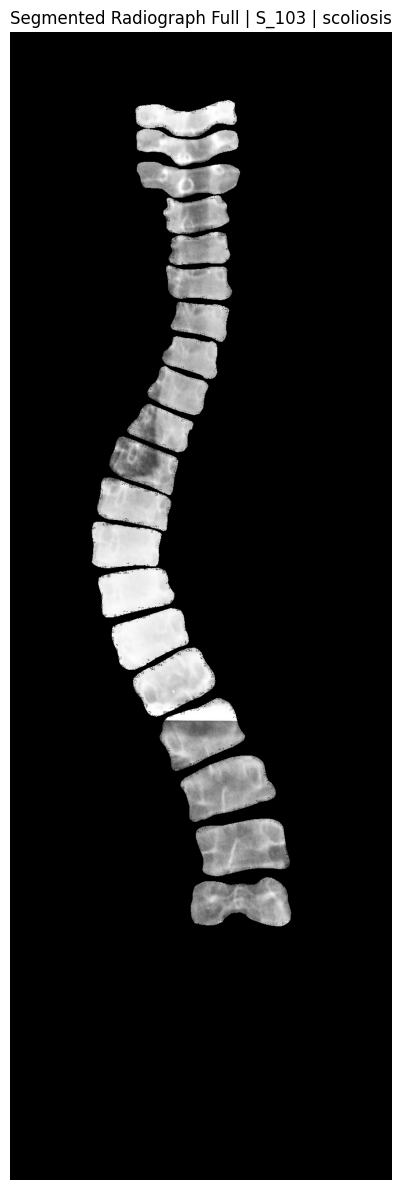

In [25]:
gray_mask_path="/content/drive/MyDrive/MaIA_Scoliosis_Dataset/LabelMultiClass_Gray_JPG/LabelMulti_S_103.jpg"
radiograph_path="/content/drive/MyDrive/MaIA_Scoliosis_Dataset/Scoliosis/S_103.jpg"

processor = VertebraGrayImageOnlyProcessor(
    class_id_to_name=class_id_to_name,
    class_id_to_gray=class_id_to_gray
)

# 3) vuelve a cargar/procesar el caso
processor.process_case_from_paths(
    gray_mask_path=gray_mask_path,
    radiograph_path=radiograph_path,
    tolerance=4,
    min_blob_area=10,
    deduplicate=True,
    overlap_threshold=0.80,
    iou_threshold=0.50
)

# 4) ahora sí llama el método
processor.show_segmented_radiograph_full()

In [26]:
import math
import numpy as np
import matplotlib.pyplot as plt


def extract_class_segmented_regions(
    self,
    class_ids=None,
    pad=8,
    fill_value=0,
    exclude_background=True,
):
    """
    Devuelve un diccionario:
        {class_id: {"class_name": str, "mask": mask, "bbox": bbox, "image": crop_img}}
    donde cada clase se construye uniendo todos sus blobs deduplicados.
    """
    self._require_radiograph()

    if not self.blob_masks_by_class:
        raise ValueError("Primero ejecuta run_audit() o extract_connected_components().")

    if class_ids is None:
        class_ids = sorted(self.blob_masks_by_class.keys())

    if exclude_background:
        class_ids = [cid for cid in class_ids if cid != 0]

    result = {}

    for class_id in class_ids:
        blob_masks = self.blob_masks_by_class.get(class_id, [])
        if not blob_masks:
            continue

        merged_mask = np.zeros_like(blob_masks[0], dtype=bool)
        for bm in blob_masks:
            merged_mask |= bm

        ys, xs = np.where(merged_mask)
        if len(ys) == 0 or len(xs) == 0:
            continue

        bbox = (int(ys.min()), int(xs.min()), int(ys.max()), int(xs.max()))

        if self.radiograph_image.shape[:2] != merged_mask.shape:
            raise ValueError(
                f"La radiografía y la máscara no tienen el mismo tamaño. "
                f"radiograph={self.radiograph_image.shape[:2]}, mask={merged_mask.shape}"
            )

        masked_full = self._apply_mask_to_image(
            self.radiograph_image,
            merged_mask,
            fill_value=fill_value
        )

        crop_img = self._crop_from_bbox(masked_full, bbox, pad=pad)

        result[int(class_id)] = {
            "class_name": self.class_id_to_name.get(class_id, str(class_id)),
            "mask": merged_mask,
            "bbox": bbox,
            "image": crop_img,
        }

    return result


def show_segmented_columns_grid(
    self,
    class_ids=None,
    pad=8,
    fill_value=0,
    columns=4,
    figsize_per_plot=(4.0, 4.8),
    show_titles=True,
    exclude_background=True,
):
    """
    Muestra un grid donde cada celda es una clase/vértebra segmentada sobre la radiografía.
    """
    regions = self.extract_class_segmented_regions(
        class_ids=class_ids,
        pad=pad,
        fill_value=fill_value,
        exclude_background=exclude_background,
    )

    items = list(regions.items())
    if not items:
        print("No hay regiones segmentadas para mostrar.")
        return

    total = len(items)
    rows = math.ceil(total / columns)

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(columns * figsize_per_plot[0], rows * figsize_per_plot[1])
    )

    axes = np.array(axes).reshape(rows, columns).flatten()

    for idx, (class_id, info) in enumerate(items):
        img = info["image"]
        class_name = info["class_name"]

        if img.ndim == 2:
            axes[idx].imshow(img, cmap="gray")
        else:
            axes[idx].imshow(img)

        if show_titles:
            axes[idx].set_title(f"{class_name}\nID={class_id}")
        axes[idx].axis("off")

    for j in range(total, len(axes)):
        axes[j].axis("off")

    title_case = getattr(self, "case_key", None)
    title_diag = getattr(self, "diagnosis", None)
    if title_case is not None or title_diag is not None:
        plt.suptitle(f"Segmented Columns Grid | {title_case} | {title_diag}", fontsize=14)

    plt.tight_layout()
    plt.show()


def show_segmented_columns_with_masks_grid(
    self,
    class_ids=None,
    pad=8,
    fill_value=0,
    columns=3,
    figsize_per_plot=(5.0, 4.5),
    exclude_background=True,
):
    """
    Grid doble:
    para cada clase muestra
    - radiografía segmentada
    - máscara binaria de esa clase
    """
    regions = self.extract_class_segmented_regions(
        class_ids=class_ids,
        pad=pad,
        fill_value=fill_value,
        exclude_background=exclude_background,
    )

    items = list(regions.items())
    if not items:
        print("No hay regiones segmentadas para mostrar.")
        return

    total = len(items)
    rows = math.ceil(total / columns)

    fig, axes = plt.subplots(
        rows * 2,
        columns,
        figsize=(columns * figsize_per_plot[0], rows * 2 * figsize_per_plot[1])
    )
    axes = np.array(axes).reshape(rows * 2, columns)

    for idx, (class_id, info) in enumerate(items):
        r = (idx // columns) * 2
        c = idx % columns

        img = info["image"]
        mask = info["mask"]
        bbox = info["bbox"]
        class_name = info["class_name"]

        # recorte de máscara con mismo bbox + pad
        y1, x1, y2, x2 = bbox
        h, w = mask.shape
        y1 = max(0, y1 - pad)
        x1 = max(0, x1 - pad)
        y2 = min(h - 1, y2 + pad)
        x2 = min(w - 1, x2 + pad)
        mask_crop = mask[y1:y2 + 1, x1:x2 + 1]

        if img.ndim == 2:
            axes[r, c].imshow(img, cmap="gray")
        else:
            axes[r, c].imshow(img)
        axes[r, c].set_title(f"{class_name} | segmentada")
        axes[r, c].axis("off")

        axes[r + 1, c].imshow(mask_crop, cmap="gray")
        axes[r + 1, c].set_title(f"{class_name} | máscara")
        axes[r + 1, c].axis("off")

    # apagar ejes sobrantes
    for rr in range(rows * 2):
        for cc in range(columns):
            linear_block = (rr // 2) * columns + cc
            if linear_block >= total:
                axes[rr, cc].axis("off")

    title_case = getattr(self, "case_key", None)
    title_diag = getattr(self, "diagnosis", None)
    if title_case is not None or title_diag is not None:
        plt.suptitle(f"Segmented Columns + Masks | {title_case} | {title_diag}", fontsize=14)

    plt.tight_layout()
    plt.show()


# parchear la clase existente
VertebraGrayImageOnlyProcessor.extract_class_segmented_regions = extract_class_segmented_regions
VertebraGrayImageOnlyProcessor.show_segmented_columns_grid = show_segmented_columns_grid
VertebraGrayImageOnlyProcessor.show_segmented_columns_with_masks_grid = show_segmented_columns_with_masks_grid

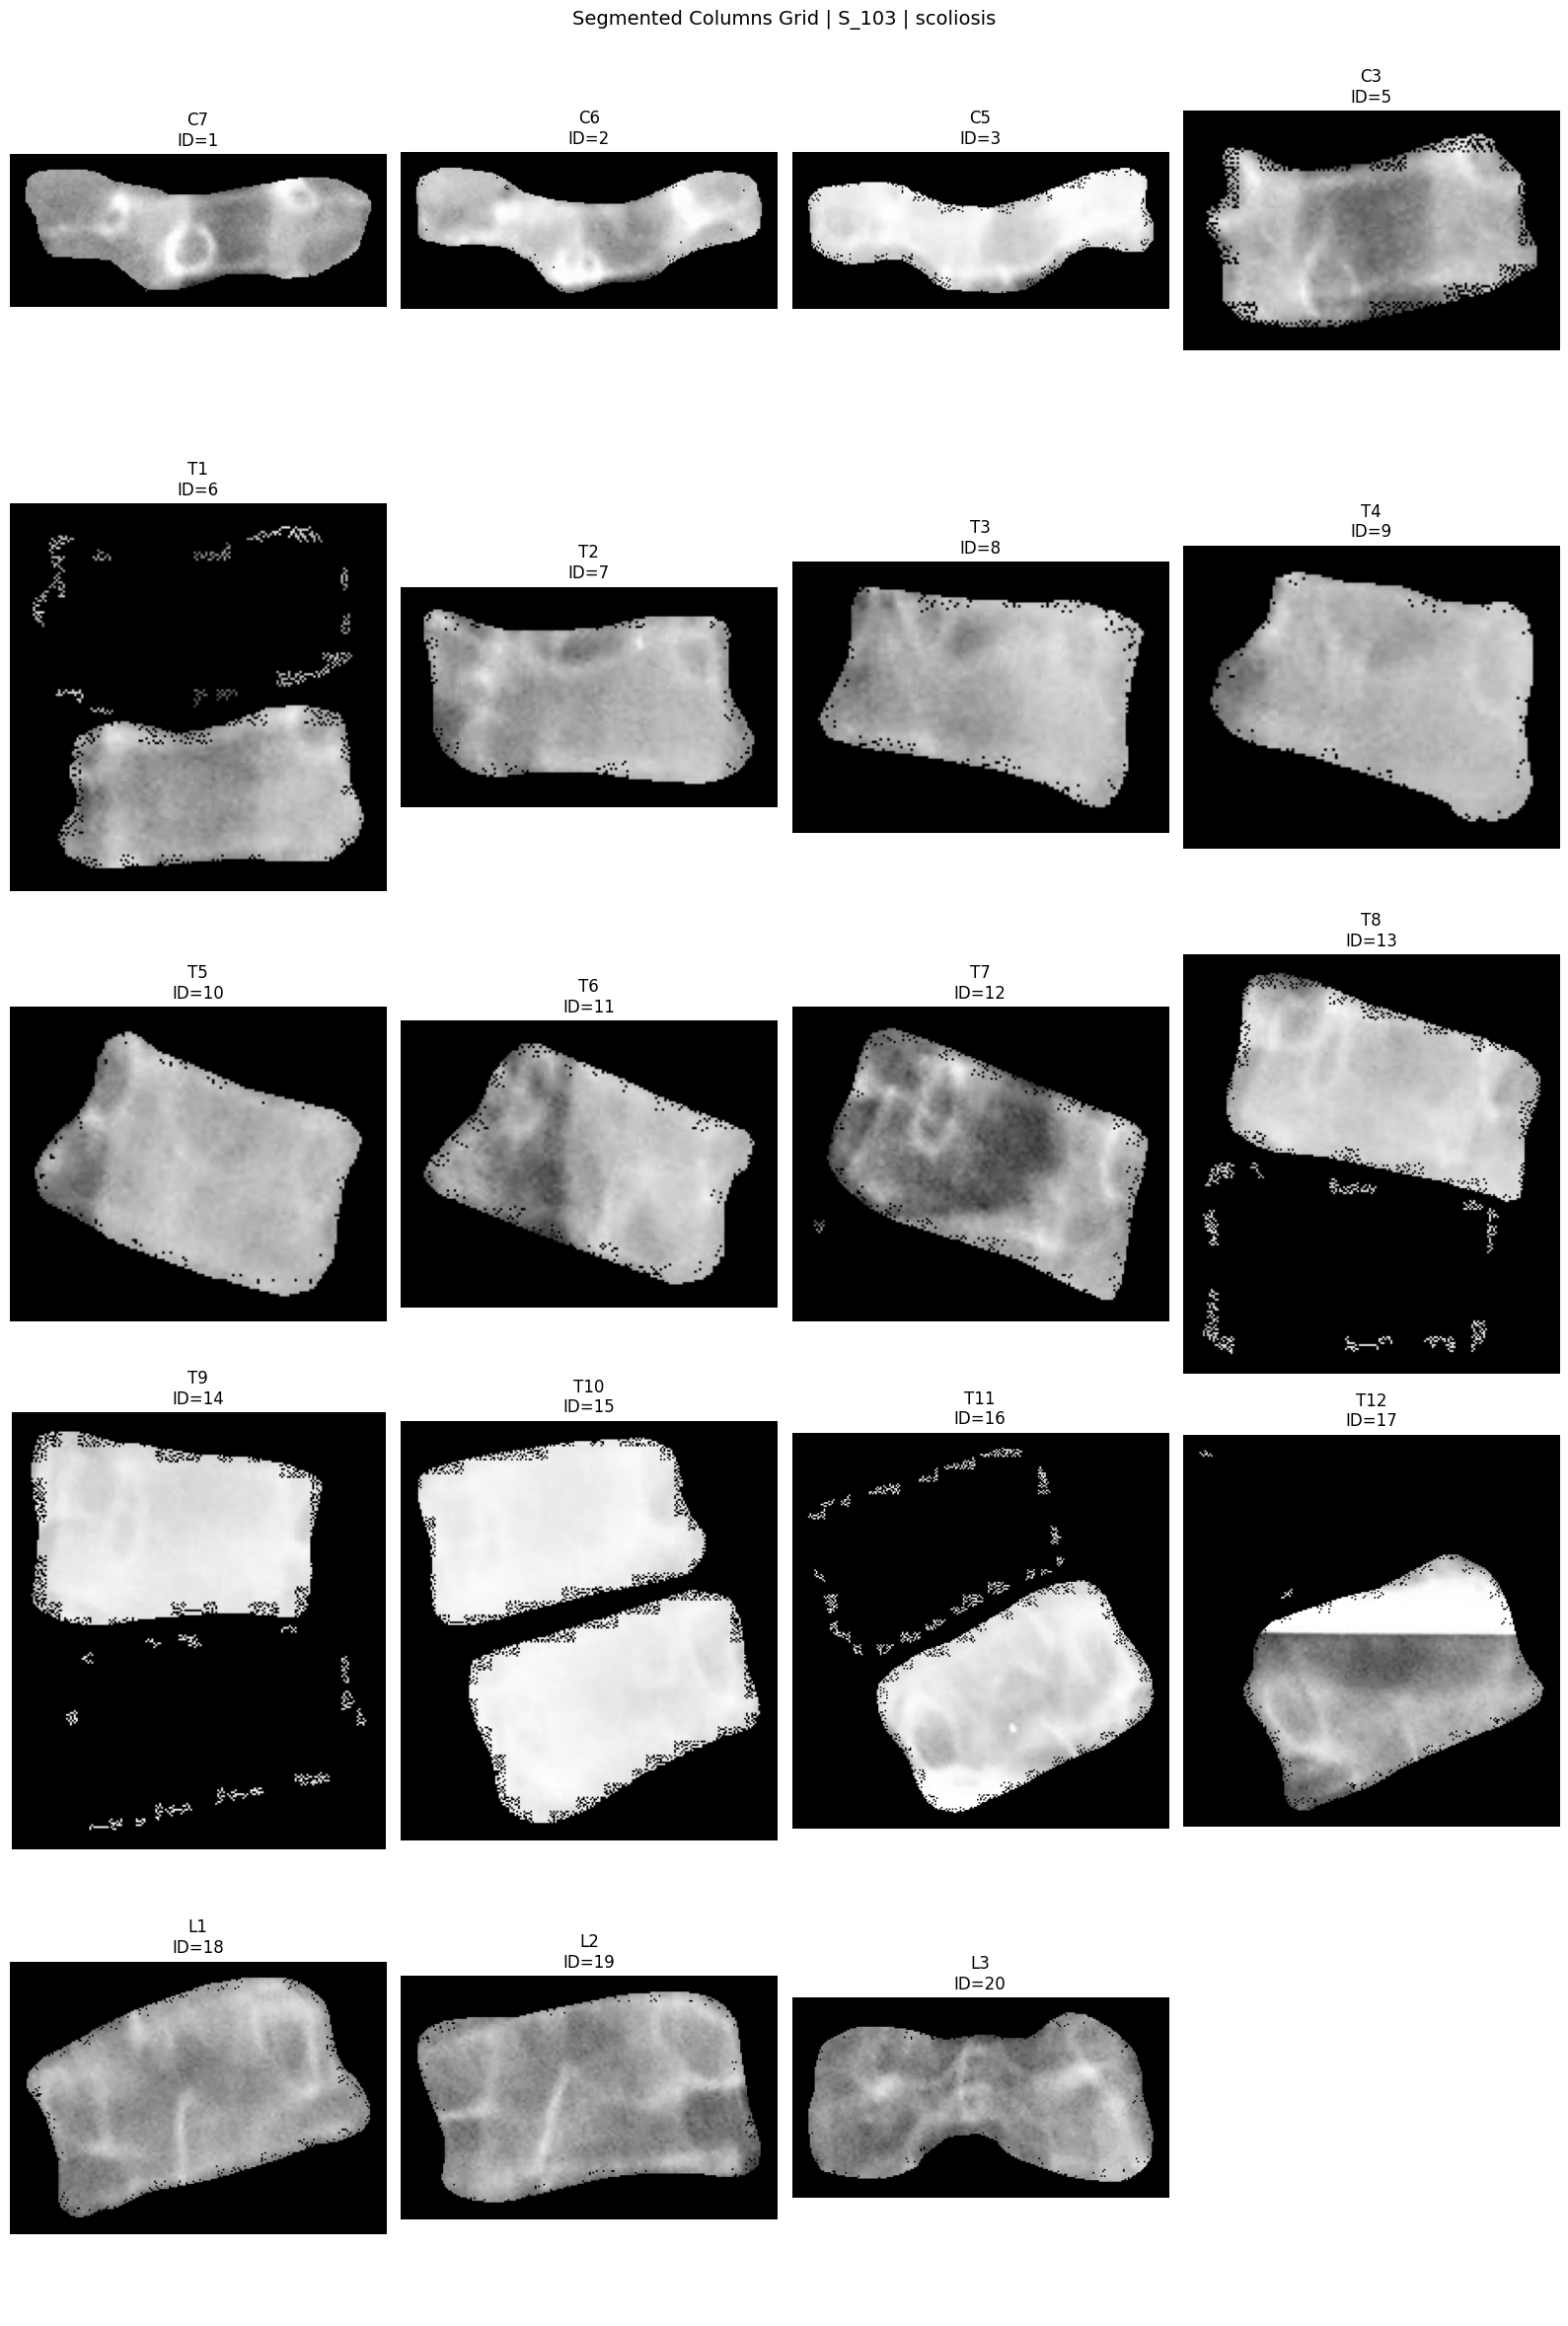

In [27]:
processor.show_segmented_columns_grid(pad=10, columns=4)

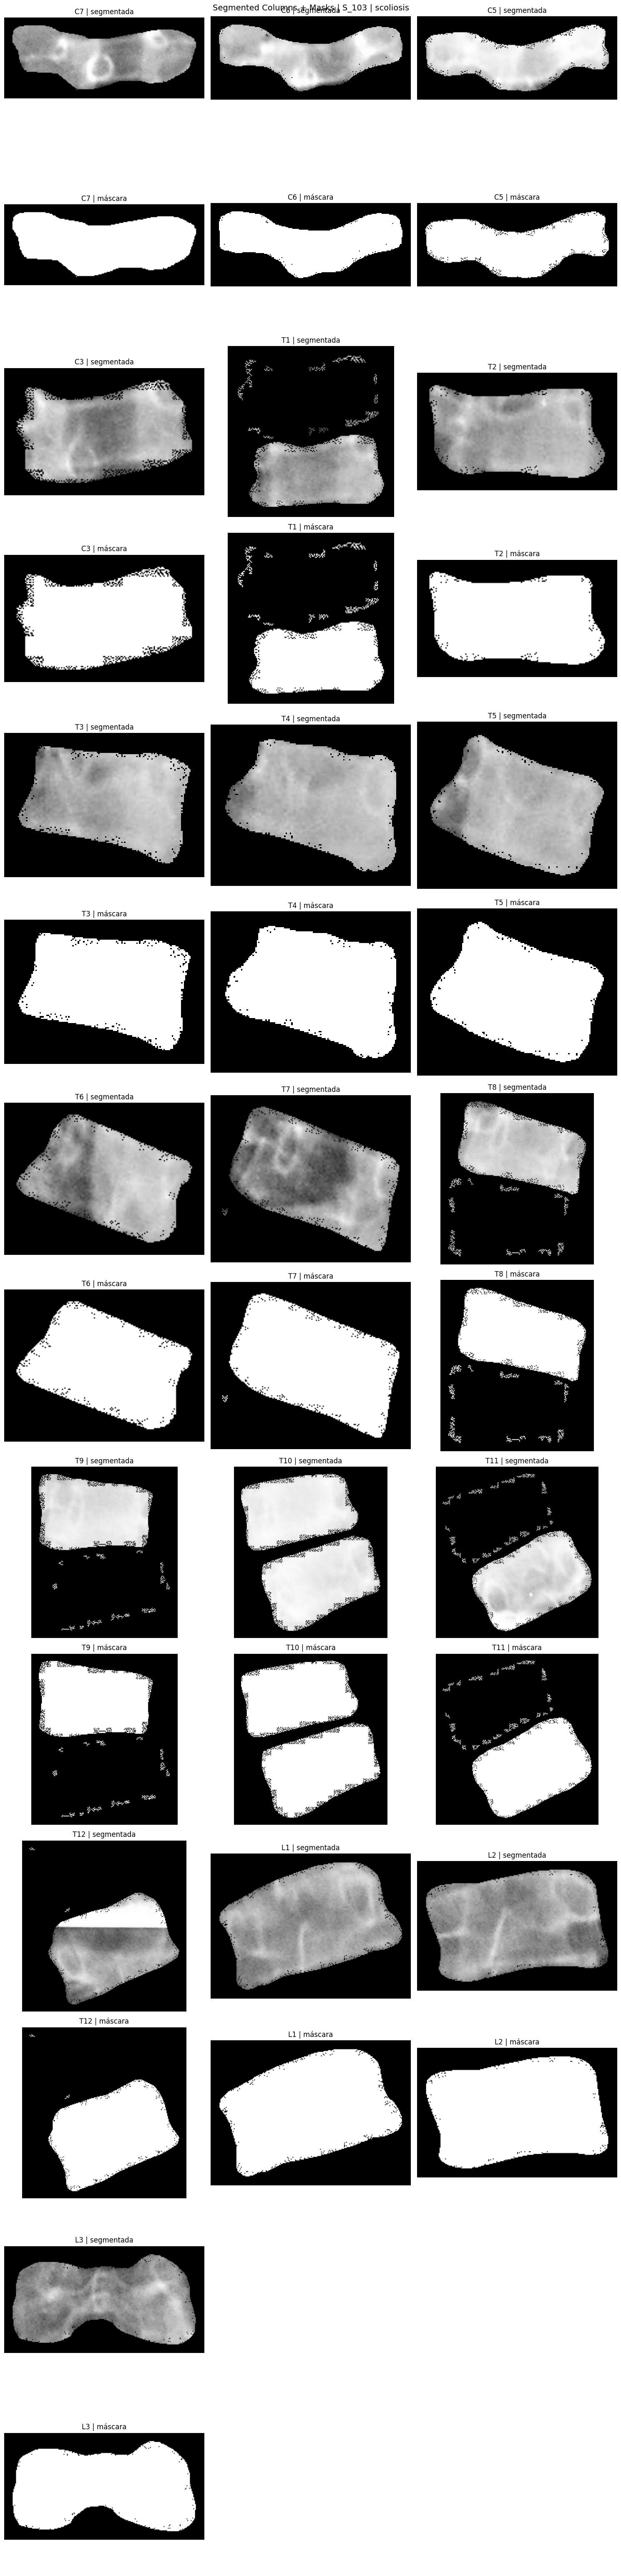

In [28]:
processor.show_segmented_columns_with_masks_grid(pad=10, columns=3)

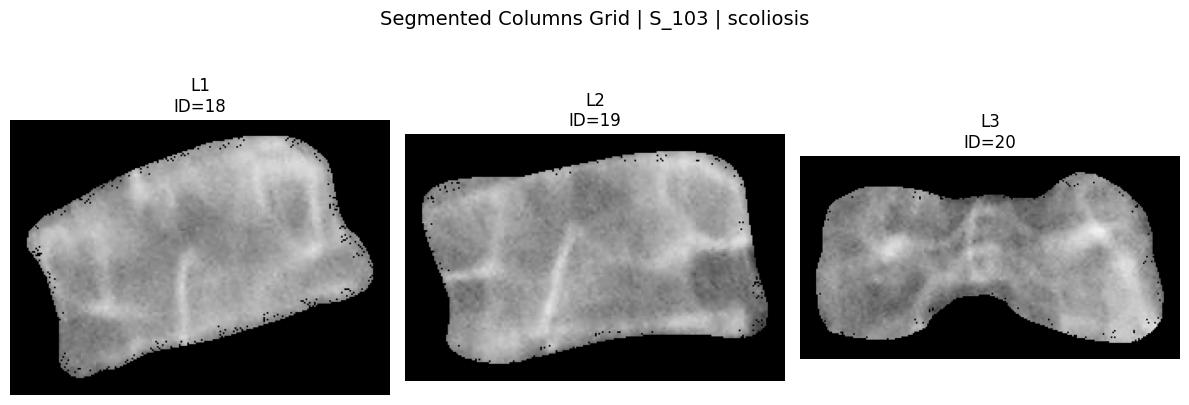

In [29]:
processor.show_segmented_columns_grid(class_ids=[18, 19, 20, 21, 22], pad=10, columns=3)